###### Content under Creative Commons Attribution license CC-BY 4.0, code under BSD 3-Clause License © 2022  by D. Koehn, T. Meier and J. Stampa, notebook style sheet by L.A. Barba, N.C. Clementi

# Digital Signal Processing: Data Pre-Processing

## Chapter 4 Exercises

### Exercise 4.1 

Equation (4.8) defines a simple linear relationship between an uncorrected, measured data series $\tilde{x}_i$ and a reference data series $x_i$. Derive the equation for the coefficient $a$ using the method of least squares. Interpret the result using correlation functions. 

**Solution**

We substitute the relationship between the corrected $\hat{x}_i$ and the uncorrected time series $\tilde{x}_i$

\begin{equation}
\hat{x}_i = a \tilde{x}_i \tag{4.8}
\end{equation}

into the objective function to be minimized

\begin{equation}
E = \sum_{i=1}^N (x_i - \hat{x}_i)^2 \tag{4.9}
\end{equation}

and obtain

\begin{equation}
E = \sum_{i=1}^N (x_i - a \tilde{x}_i)^2. \notag
\end{equation}

Differentiating with respect to the variable to be optimized, in this case the scaling factor $a$, yields:

\begin{equation}
\frac{\partial E}{\partial a} = -2\sum_{i=1}^N (x_i - a \tilde{x}_i) \tilde{x}_i.\notag
\end{equation}

As a condition for the objective function $E$ to attain a minimum, we set the derivative equal to zero.

\begin{equation}
\frac{\partial E}{\partial a} = -2\sum_{i=1}^N (x_i - a \tilde{x}_i) \tilde{x}_i = 0\notag
\end{equation}

We can simplify this somewhat by multiplying both sides by the factor $-\frac{1}{2}$.

\begin{equation}
\sum_{i=1}^N (x_i - a \tilde{x}_i) \tilde{x}_i = 0\notag
\end{equation}

Rearranging for the “optimal” scaling factor $a$ yields:

\begin{equation}
a = \frac{\sum_{i=1}^N x_i \tilde{x}_i}{\sum_{i=1}^N \tilde{x}_i \tilde{x}_i}\notag
\end{equation}

We can interpret this equation such that the zero-lag correlation between the time series $x_i$ and $\tilde{x}_i$ is normalized to the zero-lag autocorrelation of the time series $\tilde{x}_i$. 

Let's check if the result is correct by generating a time series based on two sine waves in Python ...

In [1]:
# Import Python libraries
# -----------------------
#%matplotlib inline
from ipywidgets import interactive
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.stattools import adfuller

In [2]:
def sin_func(a):
    
    # Define parameters
    T1 = 25.                 # period 1 [s]
    T2 = 500.                # period 2 [s]
    dt = .1                  # time sampling [s]
    L = 1000.                # length of the time series [s]

    # Define sine functions ...
    omega1 = 2. * np.pi / T1   # compute circular frequency from period 1
    omega2 = 2. * np.pi / T2   # compute circular frequency from period 2
    t = np.arange(0,L+dt,dt) # compute time vector
    
    x1 = np.sin(omega1*t)  # compute sine wave 1
    x2 = np.sin(omega2*t)  # compute sine wave 1
    
    # Add both sine functions
    x = a*(x1 + x2)
    
    return x, t

Using the factor a = 1, we generate an unadjusted time series xb ...

In [3]:
xb, t = sin_func(1.)

... and with the factor $a = \frac{\pi}{9.16}$, the reference time series x ...

In [4]:
x, t = sin_func(np.pi/9.16)

The plot of the reference time series and the uncorrected time series shows a clear difference in amplitude ...

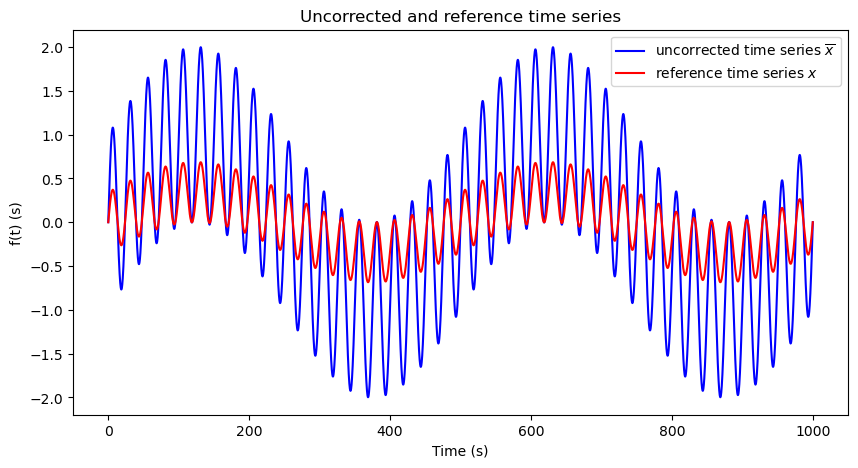

In [6]:
# Initialize Plots
plt.figure(figsize=(10,5))
    
# Plot time series
plt.plot(t, xb, 'b', label = r'uncorrected time series $\overline{x}$')
plt.plot(t, x, 'r', label = r'reference time series $x$')
plt.xlabel('Time (s)')
plt.ylabel('f(t) (s)')
plt.legend()
plt.title('Uncorrected and reference time series');

We can easily determine the optimal scaling factor $a$ by summing over the products of the time series.

In [8]:
a = np.sum(x*xb) / np.sum(xb*xb)
print(a)

0.3429686303045626


Applying the factor $a$ to the uncorrected time series shows that the two time series can be perfectly superimposed.

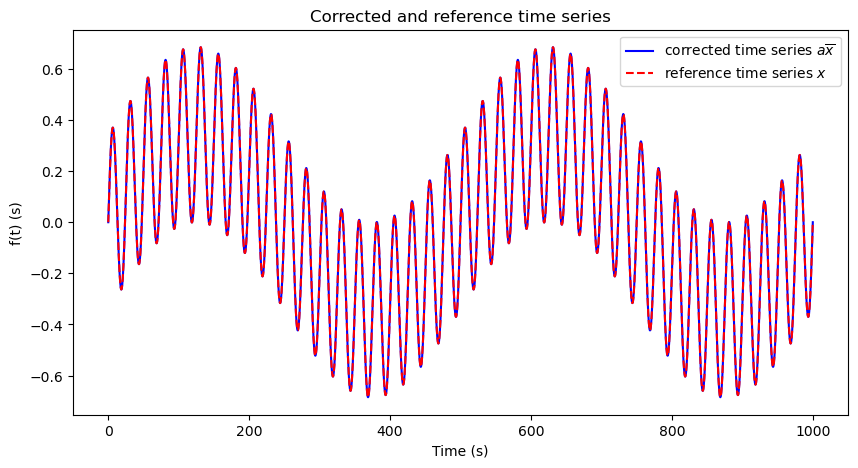

In [11]:
# Initialize Plots
plt.figure(figsize=(10,5))
    
# Plot time series
plt.plot(t, a*xb, 'b', label = r'corrected time series $a\overline{x}$')
plt.plot(t, x, 'r--', label = r'reference time series $x$')
plt.xlabel('Time (s)')
plt.ylabel('f(t) (s)')
plt.legend()
plt.title('Corrected and reference time series');

### Problem 4.2

Derive the equation for the coefficient $a$ in the case of an externally measured disturbance variable (Eq. (4.11)) using the method of least squares. Interpret this result using correlation functions.

**Solution**

As in Exercise 4.1, the optimal scaling factor $a$ in this case is given by:

\begin{equation}
a = \frac{\sum_{i=1}^N x_i \tilde{p}_i}{\sum_{i=1}^N \tilde{p}_i \tilde{p}_i}\notag
\end{equation}

### Problem 4.3

Equation (4.15) expresses a trend in the form of a polynomial. Using the method of least squares, derive the equation for the $a_k$, where $k = 0, \ldots, q$.

**Solution**

We substitute Eq. (4.15)

\begin{equation}
m_i(a_j)=a_0+ a_1t_i+a_2t_i^2+\dots + a_qt_i^q = \sum\limits_{j=0}^{q} a_j t_i^j \tag{4.15}
\end{equation}

into the objective function (4.16) to be minimized 

\begin{equation}
E=\sum\limits_{i=1}^N (x_i -m_i)^2 \rightarrow \mbox{Min.} \tag{4.16}
\end{equation}

and obtain

\begin{equation}
E=\sum\limits_{i=1}^N (x_i - \sum\limits_{j=0}^{q} a_j t_i^j)^2 \notag
\end{equation}

Differentiating with respect to the coefficient $a_k$ to be optimized and setting it to zero yields:

\begin{equation}
\frac{\partial E}{\partial a_k} = -2 \sum\limits_{i=1}^N (x_i - \sum\limits_{j=0}^{q} a_j t_i^j) t_i^k = 0\notag
\end{equation}

After dividing by -2 and performing some minor rearrangements of the sums, we obtain:

\begin{equation}
\sum\limits_{i=1}^N x_i t_i^k - \sum\limits_{i=1}^N \sum\limits_{j=0}^{q} a_j t_i^j t_i^k = 0\notag
\end {equation}

After moving the second term to the right-hand side and reversing the order of summation, we obtain the desired system of linear equations for determining the parameters $a_k$, $k=0,...,q$:
\begin{equation}
\sum_{i=1}^N x_i t_i^k = \sum_{j=0}^q a_j \sum_{i=1}^N t_i^j t_i^k. \tag{4.18}
\end{equation}

### Exercise 4.4

Verify your result by setting $q=0$. This yields an equation for determining the mean. Interpret the result: Why is this estimate of the mean optimal in the sense of the least squares method?

**Solution**

Since $q = 0$, it follows that $k$ must also be 0. From (Eq. 4.18) it follows

\begin{equation}
\sum_{i=1}^N x_i t_i^0 = \sum_{j=0}^0 a_j \sum_{i=1}^N t_i^j t_i^0. \notag
\end {equation}

Setting $t_i^0 = 1$ further simplifies the problem

\begin{equation}
\sum_{i=1}^N x_i = \sum_{j=0}^0 a_j \sum_{i=1}^N t_i^j. \notag
\end{equation}

Calculating the sum $\sum_{j=0}^0$ on the right-hand side yields

\begin{equation}
\sum_{i=1}^N x_i = a_0 \sum_{i=1}^N t_i^0. \notag
\end{equation}

Since $\sum_{i=1}^N t_i^0 = \sum_{i=1}^N 1 = N$, it follows that

\begin{equation}
\sum_{i=1}^N x_i = N a_0 \notag
\end{equation}

or the mean

\begin{equation}
a_0 = \frac{1}{N} \sum_{i=1}^N x_i. \notag
\end{equation}

That is, the best fit of a constant coefficient to a time series yields its arithmetic mean.

Let us substitute our result into Eq. (4.16)

\begin{equation}
E=\sum\limits_{i=1}^N (x_i -m_i)^2 \rightarrow \mbox{Min.} \tag{4.16}
\end{equation}

which yields 

\begin{equation}
E=\sum\limits_{i=1}^N (x_i - a_0)^2=\sum\limits_{i=1}^N (x_i - \frac{1}{N} \sum_{j=1}^N x_j)^2 \rightarrow \min. \notag
\end{equation}

That is, up to a factor of $1/(N-1)$, we effectively minimize the variance between the values of the time series $x_i$ and the mean $a_0$ with the objective function.

### Exercise 4.5

Show that a two-sided moving average of a convolution corresponds to a boxcar function. How does the spectrum of the observed data series
change as a result of the moving average?

**Solution**

We define the discrete boxcar function as 

\begin{equation}
boxcar_i := 
\begin{cases}
\frac{1}{2q+1}\; \text{for} -q <= i <= q \\
0\; \text{otherwise}
\end{cases}
\notag
\end{equation}

The convolution of the boxcar function with a time series $x_i$ yields

\begin{equation}
(boxcar * x)_i = \sum_{j=-\infty}^{\infty} boxcar_j x_{i-j}\notag
\end{equation}

or, after substituting the boxcar function and a few minor rearrangements, it immediately follows that

\begin{equation}
(boxcar * x)_i = \sum_{j=-q}^{q} \frac{1}{2q+1} x_{i-j} = \frac{1}{2q+1}\sum_{j=-q}^{q} x_{i-j} = \hat{m}_i,\notag 
\end{equation}

i.e., the discrete convolution of the boxcar function with the time series corresponds to the two-sided moving average $\hat{m}_i$.

To calculate the effect of the moving average on the spectrum of the time series $x_i$, we simply compute the Fourier transform of the boxcar function

\begin{equation}
\begin{split}
{\mathcal{F}}(boxcar)(\omega) &= \int_{-\infty}^{\infty} boxcar(t) e^{-i \omega t} dt \\
&= \frac{1}{2q}\int_{-q}^{q} e^{-i \omega t} dt \\
&= \biggl[\frac{e^{-i \omega t}}{-2qi\omega}\biggr]_{-q}^q \\
&= \frac{e^{-i \omega q}}{-2qi\omega} - \frac{e^{i \omega q}}{-2qi\omega} \\
&= \frac{e^{-i \omega q}-e^{i \omega q}}{-2qi\omega}\\
&= \frac{e^{i \omega q}+e^{-i \omega q}}{2qi\omega}.\\
\end{split}\notag
\end{equation}

Using the definition of the sine function 

\begin{equation}
sin(x) = \frac{e^{ix}+e^{-ix}}{2i},\notag 
\end{equation}

follows

\begin{equation}
\begin{split}
{\mathcal{F}}(boxcar)(\omega) &= \frac{e^{i \omega q}+e^{-i \omega q}}{2qi\omega}\\
                   &= \frac{sin(q\omega)}{q\omega}\\
                   &= sinc(q\omega),\\
\end{split}\notag
\end{equation}

which corresponds to the **sinc function**. Let’s implement this solution ...

In [13]:
def box_spec_cont(q):
    
    # Define parameters
    wmax = np.pi           # maximum frequency [rad/s]
    dw = wmax / 1000       # sample interval in frequency domain [rad/s]
    
    # Define frequency array ...
    w = np.arange(dw,wmax+dw,dw)
    
    # Compute DFT of boxcar function
    # two-sided boxcar function
    DFT = np.sin(w*q)/(w*q)
    
    return w, DFT

... and, for comparison, compute the DFT of a boxcar function of a finite time series.

In [14]:
def box_spec_DFT(q):
    
    # Define parameters
    N = 32*q
    dt = 1
    
    rect = np.zeros(N)
    rect[0:2*q] = 1./(2*q)
    
    DFT = np.fft.fft(rect)

    # estimate frequencies    
    freq = np.fft.fftfreq(N, d=dt)
    w = 2.*np.pi*freq
    
    # swap positive and negative parts of the FFT / frequencies using fftshift for 
    # correct amplitude spectrum plot of negative and positive frequencies
    DFT = np.fft.fftshift(DFT)
    w = np.fft.fftshift(w)
    
    return w, DFT

A comparison of the two solutions for a window length of q = 16 ...

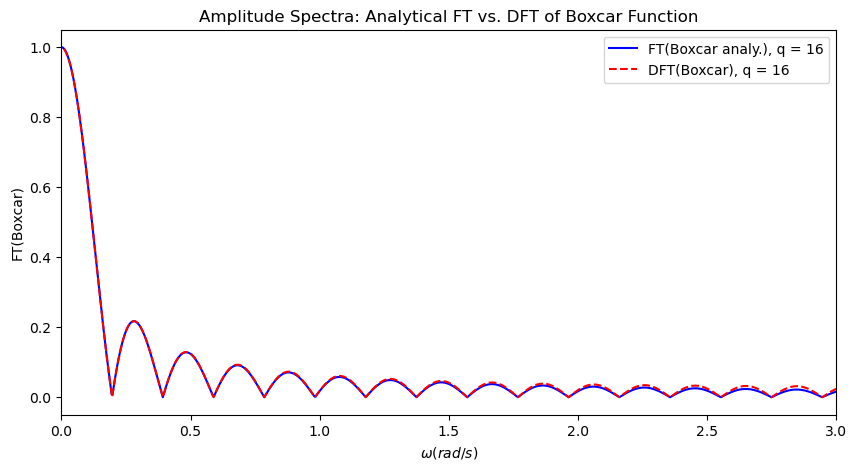

In [16]:
# Compare analytical Solution with DFT Solution with q = 16
w, DFT16_cont = box_spec_cont(16)
w1, DFT16_1 = box_spec_DFT(16)

# Initialize Plots
plt.figure(figsize=(10,5))
    
# Plot time series
plt.plot(w, np.abs(DFT16_cont), 'b-', label = r'FT(Boxcar analy.), q = 16')
plt.plot(w1, np.abs(DFT16_1), 'r--', label = r'DFT(Boxcar), q = 16')
plt.xlim(0,3)
plt.xlabel(r'$\omega (rad/s)$')
plt.ylabel('FT(Boxcar)')
plt.legend()
plt.title('Amplitude Spectra: Analytical FT vs. DFT of Boxcar Function');

... shows that the solutions agree very well for small circular wavenumbers. Finally, we can plot the amplitude spectra for different window positions.

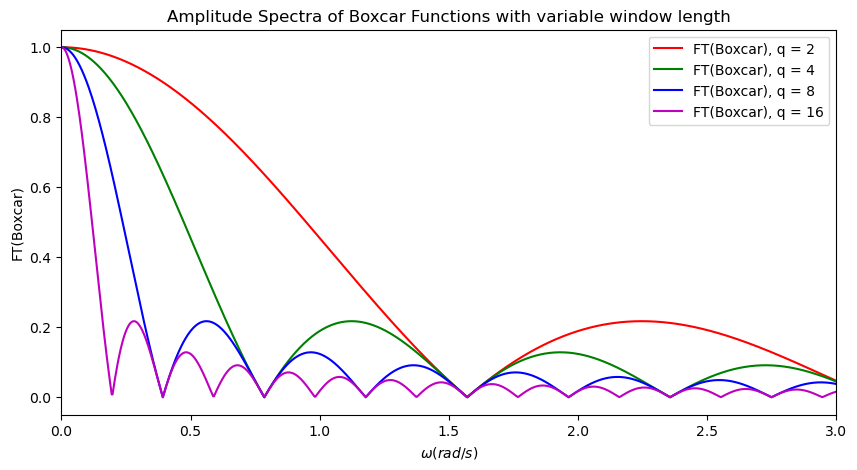

In [18]:
# compute Boxcar DFT for different window lengths
w, DFT2 = box_spec_cont(2)
w, DFT4 = box_spec_cont(4)
w, DFT8 = box_spec_cont(8)
w, DFT16 = box_spec_cont(16)

# Initialize Plots
plt.figure(figsize=(10,5))
    
# Plot time series
plt.plot(w, np.abs(DFT2), 'r', label = r'FT(Boxcar), q = 2')
plt.plot(w, np.abs(DFT4), 'g', label = r'FT(Boxcar), q = 4')
plt.plot(w, np.abs(DFT8), 'b', label = r'FT(Boxcar), q = 8')
plt.plot(w, np.abs(DFT16), 'm', label = r'FT(Boxcar), q = 16')
plt.xlim(0,3)
plt.xlabel(r'$\omega (rad/s)$')
plt.ylabel('FT(Boxcar)')
plt.legend()
plt.title('Amplitude Spectra of Boxcar Functions with variable window length');

All boxcar filters act like low-pass filters, becoming narrower in bandwidth as the window length increases. However, the filtering is not perfect, as a large number of high frequencies are also allowed to pass.

### Exercise 4.6

Define a sequence of values $x_i = m_i + n_i$. The length should be 200 s and the sampling interval 1 s. Let $n_i$ be normally distributed random variables. Assume the model $m_i = \frac{0.0001}{\mbox{s}} t_i^2$ for the trend. Perform a trend correction using a polynomial fit.

- The order for the trend correction should be 1, and the standard deviation for the random noise should also be 1.

- The order for the trend correction should be 1, and the standard deviation for the random noise should be 0.1.

- The order for the trend correction should be 2, and the standard deviation for the random noise should be 1.

- The order for trend correction should be 2, and the standard deviation for the random noise should be 0.1.

Interpret the results.

**Solution**

To solve this problem, we must find optimal coefficients for first- and second-degree polynomial approximations. To do this, we use the system of linear equations (4.18) to determine the parameters $a_k$, $k=0,...,q$:
\begin{equation}
\sum_{i=1}^N x_i t_i^k = \sum_{j=0}^q a_j \sum_{i=1}^N t_i^j t_i^k. \tag{4.18}
\end{equation}

**<ins>First-degree polynomial approximation (q=1)<ins>**

Using (4.18), the system of equations for $k = 0$ and $q = 1$ becomes

\begin{equation}
\sum_{i=1}^N x_i t_i^0 = \sum_{j=0}^1 a_j \sum_{i=1}^N t_i^j t_i^0. \notag
\end{equation}

Setting $t_i^0 = 1$ yields

\begin{equation}
\sum_{i=1}^N x_i = a_0 \sum_{i=1}^N t_i^0 t_i^0 + a_1 \sum_{i=1}^N t_i^1 t_i^0 \notag
\end{equation}

or 

\begin{equation}
\sum_{i=1}^N x_i = N a_0 + a_1 \sum_{i=1}^N t_i \tag{E1}
\end{equation}

For $k=1$ and $q=1$, it follows from Eq. (4.18)

\begin{equation}
\sum_{i=1}^N x_i t_i^1 = \sum_{j=0}^1 a_j \sum_{i=1}^N t_i^j t_i^1 \notag
\end{equation}

after evaluating the sum $\sum_{j=0}^1$ on the right-hand side

\begin{equation}
\sum_{i=1}^N x_i t_i = a_0 \sum_{i=1}^N t_i^0 t_i + a_1 \sum_{i=1}^N t_i^1 t_i\notag
\end {equation}

or 

\begin{equation}
\sum_{i=1}^N x_i t_i = a_0 \sum_{i=1}^N t_i + a_1 \sum_{i=1}^N t_i^2\tag{E2}
\end{equation}

Equations (E1) and (E2) form a system of linear equations:

\begin{equation}
N a_0 + a_1 \sum_{i=1}^N t_i = \sum_{i=1}^N x_i\tag{E1}
\end{equation}

\begin{equation}
a_0 \sum_{i=1}^N t_i + a_1 \sum_{i=1}^N t_i^2 = \sum_{i=1}^N x_i t_i\tag{E2}
\end{equation}

which we could solve explicitly for the coefficients $a_0$ and $a_1$, or we can write the system of equations as a matrix-vector equation:

\begin{equation}
\begin{pmatrix} N & \sum_{i=1}^N t_i \\ \sum_{i=1}^N t_i & \sum_{i=1}^N t_i^2 \end{pmatrix} 
\begin{pmatrix} a_0  \\ a_1 \end{pmatrix} =
\begin{pmatrix} \sum_{i=1}^N x_i \\ \sum_{i=1}^N x_i t_i \end{pmatrix}
\notag
\end{equation}

or 

\begin{equation}
M a = b,
\notag
\end{equation}

from which we can determine the coefficients via

\begin{equation}
a = M^{-1}b, 
\notag
\end{equation}

where $M^{-1}$ denotes the inverse matrix of the matrix $M$, which we can easily compute in Python.

**<ins>Second-degree polynomial model (q=2)<ins>**

Analogous to the linear case $q=1$, the following system of linear equations for the optimal coefficients $a_0, a_1, a_2$ results for the quadratic trend $q=2$:

\begin{equation}
\begin{pmatrix} N & \sum_{i=1}^N t_i & \sum_{i=1}^N t_i^2\\ \sum_{i=1}^N t_i & \sum_{i=1}^N t_i^2 & \sum_{i=1}^N t_i^3 \\
\sum_{i=1}^N t_i^2 & \sum_{i=1}^N t_i^3 & \sum_{i=1}^N t_i^4
\end{pmatrix} 
\begin{pmatrix} a_0  \\ a_1 \\ a_2\end{pmatrix} =
\begin{pmatrix} \sum_{i=1}^N x_i \\ \sum_{i=1}^N x_i t_i \\ \sum_{i=1}^N x_i t_i^2\end{pmatrix}
\notag
\end{equation}

Now we can implement the task in Python ...

In [19]:
def trend_corr(q,sn):
    
    # Define parameters
    dt = 1.                 # time sampling [s]
    L = 200.                # length of the time series [s]

    # Define time array
    t = np.arange(0,L+dt,dt) # compute time vector
    N = len(t)
    
    # Create trend ...
    m = 0.0001 * t**2
    
    # ... create normal random noise with standard deviation sn ...
    # Here I set a fixed seed to reproduce the same random numbers every time 
    # I change the parameters sn, wsta, wlta, wk, kurtosis, so the time series 
    # does not change. THIS IS A VERY BAD PRACTICE: DON'T DO THIS IF
    # IF YOUR APPLICATION HAS TO RELY ON RANDOM NUMBERS
    np.random.seed(seed=12345656)
    xnoise = np.random.normal(0., sn, N)
    
    # ... add random noise to trend
    x = m + xnoise
    
    # compute linear trend (q=1)
    if(q==1):
        
        # assemble matrix M
        M = np.matrix([[N, np.sum(t)], [np.sum(t), np.sum(t**2)]])
        
        # assemble vector b
        b = np.matrix([[np.sum(x)],[np.sum(x*t)]])
        
        # compute inverse of M and solve for optimum coefficients a
        a = np.linalg.inv(M)*b
        
        # create trend
        mopt = (float)(a[0]) + (float)(a[1]) * t
    
    # compute quadratic trend (q=2)
    if(q==2):
        
        # assemble matrix M
        M = np.matrix([[N, np.sum(t), np.sum(t**2)], 
                       [np.sum(t), np.sum(t**2), np.sum(t**3)],
                       [np.sum(t**2),np.sum(t**3),np.sum(t**4)]])
        
        # assemble vector b
        b = np.matrix([[np.sum(x)],[np.sum(x*t)],[np.sum(x*t**2)]])
        
        # compute inverse of M and solve for optimum coefficients a
        a = np.linalg.inv(M)*b
        
        # create trend
        mopt = (float)(a[0]) + (float)(a[1]) * t + (float)(a[2]) * t**2
        
    
    # Initialize Plots
    plt.figure(figsize=(20,10))
    
    plt.subplot(211)
    
    # Plot time series
    plt.plot(t, x, 'b', label = r'time series x = m + xnoise')
    if(q==1):
        plt.plot(t, mopt, 'r', label = r'linear trend (q=1)')
    if(q==2):
        plt.plot(t, mopt, 'r', label = r'quadratic trend (q=2)')    
    plt.xlabel('Time (s)')
    plt.ylabel('x(t) (s)')
    plt.legend()
    
    # Apply Dickey-Fuller test to uncorrected time series x
    res = adfuller(x)
    
    title = 'x = Noise + Trend, Dickey-Fuller Test p-value = ' + str(res[1])
    plt.title(title)
    
    plt.subplot(212)
    
    # Plot time series
    if(q==1):
        plt.plot(t, x-mopt, 'r', label = r'x - linear trend (q=1)')
    if(q==2):
        plt.plot(t, x-mopt, 'r', label = r'x - quadratic trend (q=2)')    
    plt.xlabel('Time (s)')
    plt.ylabel('x(t) (s)')
    plt.legend()
    
     # Apply Dickey-Fuller test to uncorrected time series x
    res1 = adfuller(x-mopt)
    
    title = 'Trendcorrected time series, Dickey-Fuller Test p-value = ' + str(res1[1])
    plt.title(title)

In [23]:
interactive_plot = interactive(trend_corr, q=(1, 2, 1), sn=(.1, 1, .1) )
output = interactive_plot.children[-1]
output.layout.height = '650px'
interactive_plot

interactive(children=(IntSlider(value=1, description='q', max=2, min=1), FloatSlider(value=0.5, description='s…

When noise amplitudes are large, the trend in the time series can be fitted using either a linear or a quadratic function. When noise amplitudes are small, however, only the quadratic approach allows for a successful fit. This is supported by the p-values of the Dickey-Fuller test.

### Exercise 4.7

For the model from the previous exercise, perform trend correction using a two-sided moving average. Set the standard deviation of the random noise to 1 and 0.1, respectively. Choose an appropriate length for the moving window.

In [24]:
def trend_corr_mov(q,sn):
    
    # Define parameters
    dt = 1.                 # time sampling [s]
    L = 200.                # length of the time series [s]

    # Define time array
    t = np.arange(0,L+dt,dt) # compute time vector
    N = len(t)
    
    # Create trend ...
    m = 0.0001 * t**2
    
    # ... create normal random noise with standard deviation sn ...
    # Here I set a fixed seed to reproduce the same random numbers every time 
    # I change the parameters sn, wsta, wlta, wk, kurtosis, so the time series 
    # does not change. THIS IS A VERY BAD PRACTICE: DON'T DO THIS IF
    # IF YOUR APPLICATION HAS TO RELY ON RANDOM NUMBERS
    np.random.seed(seed=12345656)
    xnoise = np.random.normal(0., sn, N)
    
    # ... add random noise to trend
    x = m + xnoise
    
    # compute trend using a two-sided moving average
    box = np.zeros(N)     # initialize boxcar function
    nbox = (int)(q // dt) # compute window length in time samples
    box[:nbox] = 1. / nbox       # define boxcar function
    
    # compute moving average by convolution of boxcar with time series
    mopt = np.convolve(box,x)
    mopt = mopt[:N]   # use only positive lags
    
    # Initialize Plots
    plt.figure(figsize=(20,10))
    
    plt.subplot(211)
    
    # Plot time series
    plt.plot(t, x, 'b', label = r'time series x = m + xnoise')
    plt.plot(t, mopt, 'r', label = r'moving average trend')    
    plt.xlabel('Time (s)')
    plt.ylabel('x(t) (s)')
    plt.legend()
    
    # Apply Dickey-Fuller test to uncorrected time series x
    res = adfuller(x)
    
    title = 'x = Noise + Trend, Dickey-Fuller Test p-value = ' + str(res[1])
    plt.title(title)
    
    plt.subplot(212)
    
    # Plot time series
    plt.plot(t, x-mopt, 'r', label = r'x - moving average')
    plt.xlabel('Time (s)')
    plt.ylabel('x(t) (s)')
    plt.legend()
    
     # Apply Dickey-Fuller test to uncorrected time series x
    res1 = adfuller(x-mopt)
    
    title = 'Trendcorrected time series, Dickey-Fuller Test p-value = ' + str(res1[1])
    plt.title(title)

In [26]:
interactive_plot = interactive(trend_corr_mov, q=(2, 200, 10), sn=(.1, 1, .1) )
output = interactive_plot.children[-1]
output.layout.height = '650px'
interactive_plot

interactive(children=(IntSlider(value=92, description='q', max=200, min=2, step=10), FloatSlider(value=0.5, de…

Depending on the noise amplitude, the window length must be adjusted to ensure that the p-values from the Dickey-Fuller test are as small as possible. If the window length is too large, the moving average will approach the arithmetic mean of the time series.

### Problem 4.8

Define a function $\cos(\omega_1 t) + 0.4 \cos(\omega_2 t)$ on the interval $(0 s, 60 s)$ for $\omega_1 = \frac{2 \pi}{20 s}$, $\omega_2 = \frac{2\pi}{1 s}$ with a sampling interval of $\Delta t = 0.1 s$. Change the sampling interval to 4 s. Use the Matlab function `resample`. Calculate the sequence of values for a sampling interval of 4 s as well. Compare and interpret the results.

**Solution**

The problem can be easily implemented in Python, for example using the `SciPy` function [resample](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.resample.html).

In [27]:
from scipy import signal

In [28]:
def cos_resamp(dtnew):

    # Define parameters
    L = 60.                # length of the time series [s]
    dt = .1                # time sampling [s]

    omega1 = 2. * np.pi / 20. # circular frequency 1
    omega2 = 2. * np.pi / 1. # circular frequency 2

    # Define cos functions ...
    t = np.arange(dt,L+dt,dt)                     # compute time vector   
    x = np.cos(omega1*t) + .4 * np.cos(omega2*t)  # compute time series

    # Compute new time vector with sample interval dtnew
    tnew = np.arange(dtnew,L+dtnew,dtnew)    # compute time vector   
    Nnew = len(tnew)                         # new number of time samples
    
    # Resample time series
    xnew = signal.resample(x, Nnew)
    #xnew = np.interp(tnew,t,x)
    
    # Initialize Plots
    plt.figure(figsize=(10,5))
    
    # Plot time series
    plt.plot(t, x, 'b', label = r'x(t), dt = .1 s')
    label = r'$x_{new}(t),\; dt_{new} = $' + str(dtnew) + ' s'
    plt.plot(tnew, xnew, 'r', label = label)
    plt.xlabel(r'Time [s]')
    plt.ylabel(r'$\cos(\omega_1 t) + 0.4 \cos(\omega_2 t)$')
    plt.legend(loc='upper right')
    title = 'Resampling of time series x(t) from dt = .1 s to dtresamp = ' + str(dtnew) + ' s' 
    plt.title(title)
    
    print('len(tnew) = ', len(tnew))
    print('len(t) = ', len(t))

In [32]:
interactive_plot = interactive(cos_resamp, dtnew=(0.1, 4., 1.))
output = interactive_plot.children[-1]
output.layout.height = '550px'
interactive_plot

interactive(children=(FloatSlider(value=1.1, description='dtnew', max=4.0, min=0.1, step=1.0), Output(layout=L…

Resampling the time series works for small increases in the sample interval. Larger sample intervals result in aliasing in the resampled time series.

### Problem 4.9

Define a function $e^{-\alpha t} \sin(\omega_0 t)$ on the interval $(0 s, 40 s)$ for $\omega_0 = \frac{2 \pi}{20 s}$, $\Delta t = 2 s$, and $\alpha = \frac{1}{20 s}$. Compute the amplitude spectrum and plot it graphically. Add zeros in the interval $(40 s, 120 s)$. How does the amplitude spectrum change? Interpret the results.

**Solution**

To solve this problem, we simply need to calculate and plot the time series and its corresponding amplitude spectrum.

In [37]:
def resample_spec(Nzero):
    
    # Define parameters
    dt = 2.                  # time sampling [s]
    L = 40.                  # length of the time series [s]

    # Define sine function ...
    t = np.arange(0.,L+dt,dt)      # compute time vector
    
    omega = 2. * np.pi / 20.      # circular frequency of sine wave
    alpha = 1. / 20.              # damping parameter alpha in exponential function
    
    s = np.exp(-alpha*t) * np.sin(omega*t) # compute exponential damping + sine wave
    
    # Add zeros to the time series
    zeros = np.zeros(Nzero)
    s = np.hstack((s, zeros))
    
    # Compute new time vector
    N = len(s)               # length of the time series [#samples]
    t = np.arange(0.,(N*dt),dt)      # compute time vector
    
    # Fourier transform
    S = np.fft.fft(s)
    
    # Normalize by length of the time series
    S = S / (N*dt)
    
    # estimate frequencies    
    freq = np.fft.fftfreq(N, d=dt)

    # apply fft shift
    S = np.fft.fftshift(S)
    freq = np.fft.fftshift(freq)
    
    # Initialize Plots
    plt.figure(figsize=(20,10))
    
    # Plot time series
    plt.subplot(211)
    
    plt.plot(t, s, 'r',label=r'$e^{-\alpha t}sin(\omega t)$')
    plt.legend(loc='upper right')
    plt.xlabel('Time (s)')
    plt.ylabel('s(t) (s)')
    plt.xlim(0.,np.max(t))    
    plt.title(r'Resampling of frequency domain by adding zeros')
    
    # Plot Spectrum
    plt.subplot(212)
    
    plt.plot(freq, np.abs(S), 'b')
    plt.xlabel('Freq (Hz)')
    plt.ylabel('Amplitude |X(freq)|')
    plt.title(r'Amplitude spectrum of Time Series $s$')
    plt.xlim(0., .24)

In [38]:
interactive_plot = interactive(resample_spec, Nzero=(0, 200, 10))
output = interactive_plot.children[-1]
output.layout.height = '600px'
interactive_plot

interactive(children=(IntSlider(value=100, description='Nzero', max=200, step=10), Output(layout=Layout(height…

Adding zeros to the end of the time series reduces the sampling interval in the frequency domain. However, this effectively introduces a data gap in the time series, which, according to [the lecture](https://github.com/daniel-koehn/Digital-Signal-Processing-in-Geophysics/blob/main/Lectures/Chapter_04_Data_Pre-Processing/01_Influence_of_Data_Gaps_on_the_Spectrum.ipynb), should lead to the occurrence of secondary peaks in the frequency domain. In this example, the secondary peaks are not clearly pronounced because the function decays exponentially, but they are somewhat visible in the amplitude spectrum.